#  Analyse du Comportement d'Achat des Clients (Maroc)
## 1. Chargement et Nettoyage des Données
Ce bloc permet d'importer les bibliothèques nécessaires (`pandas`, `matplotlib`, `seaborn`) et de charger notre dataset des transactions pour préparer les analyses temporelles.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style graphique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Chargement du fichier CSV
df = pd.read_csv('transactions_clients_maroc.csv')

# 2. Conversion et formatage des dates
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['OrderMonth'] = df['Transaction_Date'].dt.to_period('M')

print(f"Dataset chargé avec succès : {df.shape[0]} lignes et {df['Customer_ID'].nunique()} clients uniques.")
display(df.head(3))

Dataset chargé avec succès : 800 lignes et 178 clients uniques.


,Transaction_ID,Customer_ID,Transaction_Date,Category,Unit_Price,Quantity,Total_Amount,Payment_Method,City,Gender,Age,OrderMonth
0,TXN_0001,CUST_035,2024-10-15,Maison,240.68,3,722.04,Livraison,Fès,F,63,2024-10
1,TXN_0002,CUST_028,2024-05-14,Électronique,1284.27,2,2568.54,Carte Bancaire,Casablanca,F,64,2024-05
2,TXN_0003,CUST_023,2024-03-02,Alimentation,1486.25,2,2972.50,Virement,Marrakech,M,44,2024-03


## 2. Analyse Exploratoire des Données (EDA) & Visualisations
Cette section met en valeur :
* Le Chiffre d'Affaires généré par ville.
* Les préférences des clients concernant les modes de paiement.
* La tendance mensuelle globale des ventes.

/tmp/xpython_42/3609232244.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ca_city.values, y=ca_city.index, ax=axes[0], palette='viridis')
/tmp/xpython_42/3609232244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Payment_Method', order=df['Payment_Method'].value_counts().index, ax=axes[1], palette='Set2')


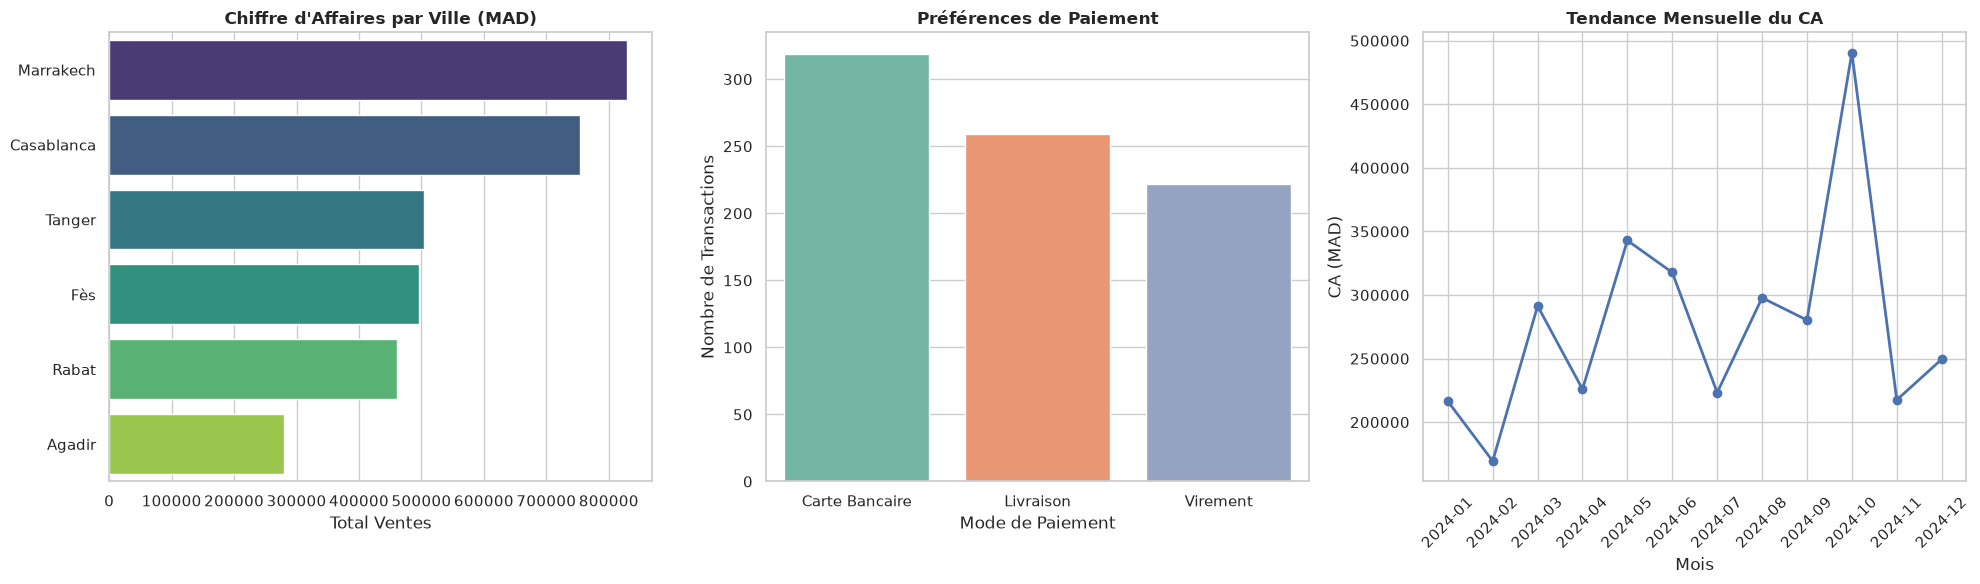

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A. Chiffre d'Affaires par Ville
ca_city = df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False)
sns.barplot(x=ca_city.values, y=ca_city.index, ax=axes[0], palette='viridis')
axes[0].set_title('Chiffre d\'Affaires par Ville (MAD)', fontweight='bold')
axes[0].set_xlabel('Total Ventes')
axes[0].set_ylabel('')

# B. Répartition des Modes de Paiement
sns.countplot(data=df, x='Payment_Method', order=df['Payment_Method'].value_counts().index, ax=axes[1], palette='Set2')
axes[1].set_title('Préférences de Paiement', fontweight='bold')
axes[1].set_xlabel('Mode de Paiement')
axes[1].set_ylabel('Nombre de Transactions')

# C. Tendance Mensuelle des Ventes
monthly_sales = df.groupby('OrderMonth')['Total_Amount'].sum()
axes[2].plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='b', linewidth=2)
axes[2].set_title('Tendance Mensuelle du CA', fontweight='bold')
axes[2].set_xlabel('Mois')
axes[2].set_ylabel('CA (MAD)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Analyse de Rétention (Matrice de Cohortes)
L'objectif de cette matrice est de suivre le taux de fidélisation des clients mois par mois après leur premier achat, un KPI stratégique pour évaluer l'engagement et la rétention.

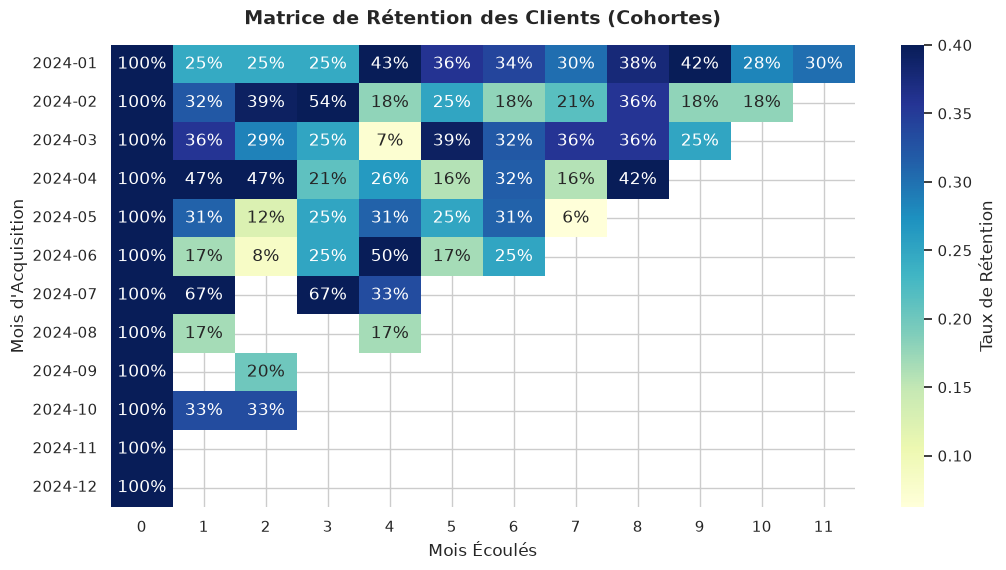

In [7]:
# 1. Mois de la première commande (Cohorte d'acquisition)
df['CohortMonth'] = df.groupby('Customer_ID')['Transaction_Date'].transform('min').dt.to_period('M')

# 2. Agrégation des clients actifs par cohorte et mois
cohort_data = df.groupby(['CohortMonth', 'OrderMonth']).agg(n_customers=('Customer_ID', 'nunique')).reset_index()

# 3. Calcul du nombre de mois écoulés
cohort_data['PeriodNumber'] = (cohort_data['OrderMonth'] - cohort_data['CohortMonth']).apply(lambda x: x.n)

# 4. Table pivot
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='PeriodNumber', values='n_customers')

# 5. Calcul du pourcentage de rétention
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 6. Affichage de la Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix, 
            annot=True, 
            fmt='.0%', 
            cmap='YlGnBu', 
            vmax=0.4,
            cbar_kws={'label': 'Taux de Rétention'})

plt.title('Matrice de Rétention des Clients (Cohortes)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Mois d\'Acquisition')
plt.xlabel('Mois Écoulés')
plt.yticks(rotation=0)
plt.show()

## Interprétation Économique des Résultats (EDA)

### 1. Chiffre d'Affaires par Ville
Marrakech et Casablanca dominent largement le CA (environ 750 000 à 800 000 MAD chacune), soit près de 50% du CA total à elles deux. Cela reflète probablement leur poids démographique et touristique. Tanger et Fès forment un second groupe intermédiaire (~500 000 MAD), tandis qu'Agadir reste en retrait (~290 000 MAD), ce qui peut indiquer un marché moins pénétré ou un potentiel de croissance inexploité dans cette ville.

Implication business : concentrer les efforts marketing sur Marrakech/Casablanca pour maximiser le ROI à court terme, tout en explorant les freins à la croissance à Agadir (logistique, concurrence locale, pouvoir d'achat).

### 2. Préférences de Paiement
La carte bancaire est le mode dominant (~320 transactions), suivie du paiement à la livraison (~260) et enfin du virement (~220). La prédominance de la carte bancaire suggère une clientèle relativement digitalisée et confiante dans les transactions en ligne. Le paiement à la livraison, encore significatif, traduit une méfiance résiduelle ou un besoin de vérifier le produit avant paiement — comportement typique du e-commerce dans les marchés émergents.

Implication business : investir dans la sécurisation et la fluidité du paiement par carte (déjà le canal préféré) tout en maintenant l'option "paiement à la livraison" comme filet de conversion pour les clients hésitants.

### 3. Tendance Mensuelle du CA
Le CA est **très volatile** tout au long de l'année, avec un pic marqué en octobre 2024 (~490 000 MAD) et des creux en février et novembre (~200-220 000 MAD). Cette saisonnalité pourrait être liée à des événements commerciaux (soldes, rentrée, périodes touristiques) ou à des campagnes promotionnelles ponctuelles plutôt qu'à une croissance organique stable.

**Implication business** : l'absence de tendance haussière claire sur 12 mois est un signal d'alerte — la croissance semble tirée par des pics ponctuels plutôt que par une dynamique de fond. Il serait utile d'identifier la cause du pic d'octobre pour la répliquer.

### 4. Matrice de Rétention des Clients (Cohortes)
La rétention chute drastiquement dès le premier mois : de 100% à seulement 25-50% en moyenne pour la plupart des cohortes. Cela signifie qu'une majorité de clients n'effectue qu'un seul achat. Les cohortes plus anciennes (janvier-avril 2024) montrent une meilleure "survie" sur le long terme (jusqu'à 11 mois), mais avec des taux qui restent globalement faibles (20-40%).

Implication business : le principal problème économique n'est pas l'acquisition (le volume de nouveaux clients semble correct) mais la fidélisation. Le coût d'acquisition client (CAC) risque de ne pas être rentabilisé si la majorité des clients ne reviennent pas — il est prioritaire de mettre en place des actions de rétention (programme de fidélité, relances email/SMS, offres de réachat).


### Synthèse Globale
L'activité repose sur deux pôles urbains forts (Marrakech, Casablanca) et un mode de paiement dominant (carte bancaire), mais souffre d'une forte instabilité mensuelle et surtout d'une faible fidélisation client. La priorité stratégique devrait basculer de l'acquisition vers la rétention pour stabiliser et pérenniser le CA.